# EDA Explration

In [9]:
import pandas as pd
import numpy as np

In [10]:
data_path="D:/Master Mohamed Nasr 2025-2026/Winter/ML/Project/Flask_ai_an/notebook/dataset/stroke_risk_dataset_uncleaned.csv"
df=pd.read_csv(data_path)
df
print("Shape:", df.shape)
display(df.head(3))

Shape: (70000, 18)


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0,0,54,58.0,1
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,0,49,40.5,0
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0,62,52.0,1


In [11]:
display(df.dtypes)


df["Age"] = pd.to_numeric(df["Age"], errors="coerce")


df["Stroke Risk (%)"] = pd.to_numeric(df["Stroke Risk (%)"], errors="coerce")


Chest Pain                        float64
Shortness of Breath               float64
Irregular Heartbeat               float64
Fatigue & Weakness                float64
Dizziness                         float64
Swelling (Edema)                  float64
Pain in Neck/Jaw/Shoulder/Back    float64
Excessive Sweating                float64
Persistent Cough                  float64
Nausea/Vomiting                   float64
High Blood Pressure               float64
Chest Discomfort (Activity)       float64
Cold Hands/Feet                   float64
Snoring/Sleep Apnea                 int64
Anxiety/Feeling of Doom             int64
Age                                 int64
Stroke Risk (%)                   float64
At Risk (Binary)                    int64
dtype: object

In [12]:
df.dtypes

Chest Pain                        float64
Shortness of Breath               float64
Irregular Heartbeat               float64
Fatigue & Weakness                float64
Dizziness                         float64
Swelling (Edema)                  float64
Pain in Neck/Jaw/Shoulder/Back    float64
Excessive Sweating                float64
Persistent Cough                  float64
Nausea/Vomiting                   float64
High Blood Pressure               float64
Chest Discomfort (Activity)       float64
Cold Hands/Feet                   float64
Snoring/Sleep Apnea                 int64
Anxiety/Feeling of Doom             int64
Age                                 int64
Stroke Risk (%)                   float64
At Risk (Binary)                    int64
dtype: object

In [13]:
unique_summary = pd.DataFrame({
    "n_unique": df.nunique(dropna=False),
    "unique_values_sample": df.apply(lambda s: sorted(s.dropna().unique())[:10])
})
display(unique_summary.sort_values("n_unique"))


,n_unique,unique_values_sample
Snoring/Sleep Apnea,2,"[0, 1]"
Anxiety/Feeling of Doom,2,"[0, 1]"
At Risk (Binary),2,"[0, 1]"
Chest Pain,3,"[0.0, 1.0]"
Dizziness,3,"[0.0, 1.0]"
Swelling (Edema),3,"[0.0, 1.0]"
Irregular Heartbeat,3,"[0.0, 1.0]"
Shortness of Breath,3,"[0.0, 1.0]"
Excessive Sweating,3,"[0.0, 1.0]"
Pain in Neck/Jaw/Shoulder/Back,3,"[0.0, 1.0]"


In [14]:
df["At Risk (Binary)"].value_counts()
df["At Risk (Binary)"].value_counts(normalize=True) * 100

At Risk (Binary)
1    64.92
0    35.08
Name: proportion, dtype: float64

In [15]:
df["Stroke Risk (%)"].describe()

count    70000.000000
mean        55.558771
std         14.300898
min          5.000000
25%         45.500000
50%         55.500000
75%         66.000000
max        100.000000
Name: Stroke Risk (%), dtype: float64

In [16]:
df.groupby("At Risk (Binary)")["Stroke Risk (%)"].describe()

,count,mean,std,min,25%,50%,75%,max
At Risk (Binary),,,,,,,,
0,24556.0,40.175273,7.146984,5.0,36.0,41.5,46.0,49.5
1,45444.0,63.871358,9.510467,50.0,56.0,62.5,70.0,100.0


In [17]:
df.groupby("At Risk (Binary)")["Stroke Risk (%)"].mean()

At Risk (Binary)
0    40.175273
1    63.871358
Name: Stroke Risk (%), dtype: float64

In [18]:
df["Age"].describe()


count    70000.000000
mean        54.056429
std         21.071567
min         18.000000
25%         36.000000
50%         54.000000
75%         72.000000
max         90.000000
Name: Age, dtype: float64

In [19]:
df[df["Stroke Risk (%)"] > 100]
df[df["Stroke Risk (%)"] < 0]

df[df["Age"] > 120]
df[df["Age"] < 0]

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)


In [20]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(3)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

display(missing_summary)

,Missing Count,Missing %
Swelling (Edema),92,0.131
Chest Pain,90,0.129
Chest Discomfort (Activity),88,0.126
Cold Hands/Feet,87,0.124
Persistent Cough,85,0.121
Fatigue & Weakness,80,0.114
Dizziness,75,0.107
Irregular Heartbeat,66,0.094
Nausea/Vomiting,66,0.094
Pain in Neck/Jaw/Shoulder/Back,56,0.080


In [21]:
missing_only = missing_summary[missing_summary['Missing Count'] > 0]
display(missing_only)

,Missing Count,Missing %
Swelling (Edema),92,0.131
Chest Pain,90,0.129
Chest Discomfort (Activity),88,0.126
Cold Hands/Feet,87,0.124
Persistent Cough,85,0.121
Fatigue & Weakness,80,0.114
Dizziness,75,0.107
Irregular Heartbeat,66,0.094
Nausea/Vomiting,66,0.094
Pain in Neck/Jaw/Shoulder/Back,56,0.080


In [22]:
rows_with_missing = df.isna().any(axis=1).sum()
rows_without_missing = (~df.isna().any(axis=1)).sum()

print("Rows with at least one missing value:", rows_with_missing)
print("Complete rows (no missing):", rows_without_missing)

Rows with at least one missing value: 945
Complete rows (no missing): 69055


In [23]:
feature_cols = [col for col in df.columns if col not in ['Stroke Risk (%)', 'At Risk (Binary)']]

feature_missing = df[feature_cols].isna().sum().sort_values(ascending=False)
feature_missing_pct = (df[feature_cols].isna().mean() * 100).sort_values(ascending=False)

feature_missing_summary = pd.DataFrame({
    'Missing Count': feature_missing,
    'Missing %': feature_missing_pct.round(3)
})

display(feature_missing_summary[feature_missing_summary['Missing Count'] > 0])

,Missing Count,Missing %
Swelling (Edema),92,0.131
Chest Pain,90,0.129
Chest Discomfort (Activity),88,0.126
Cold Hands/Feet,87,0.124
Persistent Cough,85,0.121
Fatigue & Weakness,80,0.114
Dizziness,75,0.107
Irregular Heartbeat,66,0.094
Nausea/Vomiting,66,0.094
High Blood Pressure,56,0.080


In [24]:
from sklearn.impute import SimpleImputer

binary_cols = [col for col in df.columns 
               if col not in ["Age", "Stroke Risk (%)", "At Risk (Binary)"]]

imputer = SimpleImputer(strategy="most_frequent")

df[binary_cols] = imputer.fit_transform(df[binary_cols])

In [25]:
df[binary_cols] = df[binary_cols].astype(int)

In [26]:
df.isna().sum()

Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
dtype: int64

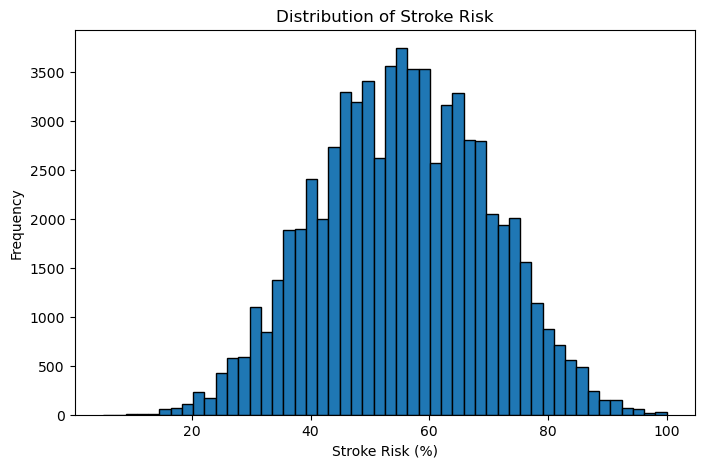

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Stroke Risk (%)"], bins=50, edgecolor="black")
plt.xlabel("Stroke Risk (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Stroke Risk")
plt.show()

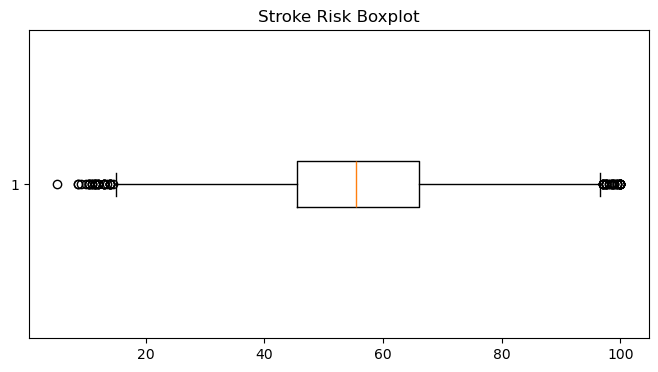

In [28]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Stroke Risk (%)"], vert=False)
plt.title("Stroke Risk Boxplot")
plt.show()

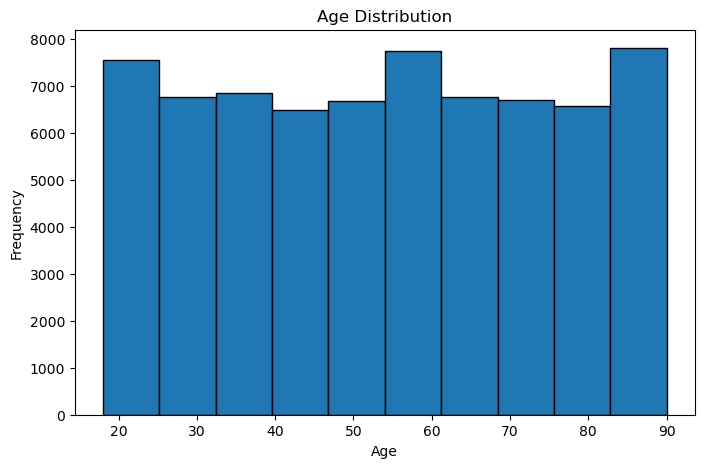

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [30]:
df["Age"].value_counts().sort_index()

Age
18     925
19     975
20     933
21     951
22     892
      ... 
86     952
87     951
88    1018
89     993
90     939
Name: count, Length: 73, dtype: int64

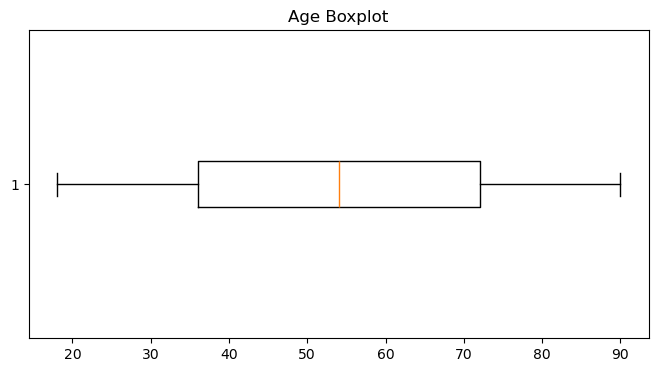

In [31]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Age"], vert=False)
plt.title("Age Boxplot")
plt.show()

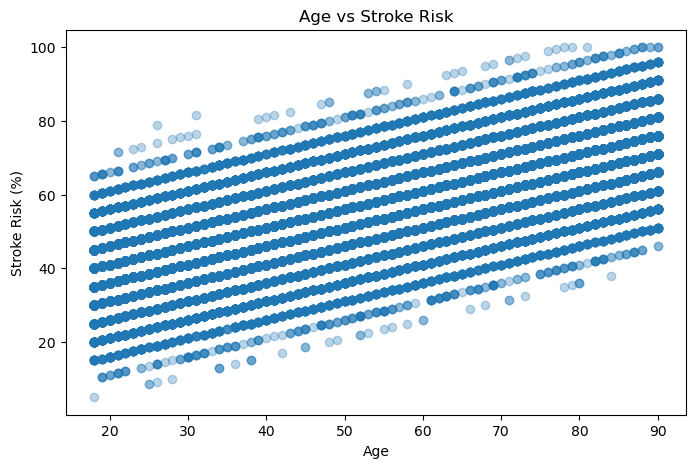

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Stroke Risk (%)"], alpha=0.3)

plt.xlabel("Age")
plt.ylabel("Stroke Risk (%)")
plt.title("Age vs Stroke Risk")

plt.show()

In [33]:
df[["Age", "Stroke Risk (%)"]].corr()

,Age,Stroke Risk (%)
Age,1.000000,0.733862
Stroke Risk (%),0.733862,1.000000


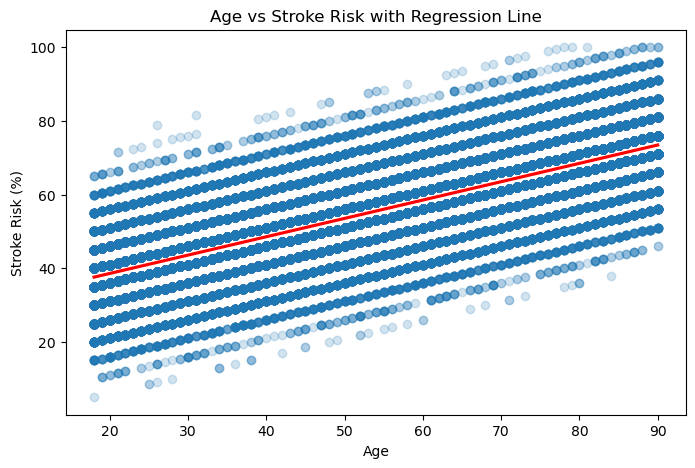

In [34]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    x="Age",
    y="Stroke Risk (%)",
    data=df,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Age vs Stroke Risk with Regression Line")
plt.show()

In [35]:
binary_cols = [col for col in df.columns 
               if col not in ["Age", "Stroke Risk (%)", "At Risk (Binary)"]]

impact = []

for col in binary_cols:
    
    risk_with = df[df[col]==1]["Stroke Risk (%)"].mean()
    risk_without = df[df[col]==0]["Stroke Risk (%)"].mean()
    
    impact.append({
        "Symptom": col,
        "Risk with symptom": risk_with,
        "Risk without symptom": risk_without,
        "Impact": risk_with - risk_without
    })

impact_df = pd.DataFrame(impact)

impact_df.sort_values("Impact", ascending=False)

,Symptom,Risk with symptom,Risk without symptom,Impact
0,Chest Pain,58.168690,52.922321,5.246368
12,Cold Hands/Feet,58.145048,52.990462,5.154587
13,Snoring/Sleep Apnea,58.129636,52.980845,5.148791
10,High Blood Pressure,58.113215,52.993357,5.119857
1,Shortness of Breath,58.121727,53.036353,5.085374
3,Fatigue & Weakness,58.086520,53.024660,5.061860
14,Anxiety/Feeling of Doom,58.081807,53.037033,5.044773
7,Excessive Sweating,58.042628,53.034564,5.008064
4,Dizziness,58.042434,53.040380,5.002054
9,Nausea/Vomiting,58.011743,53.081855,4.929888


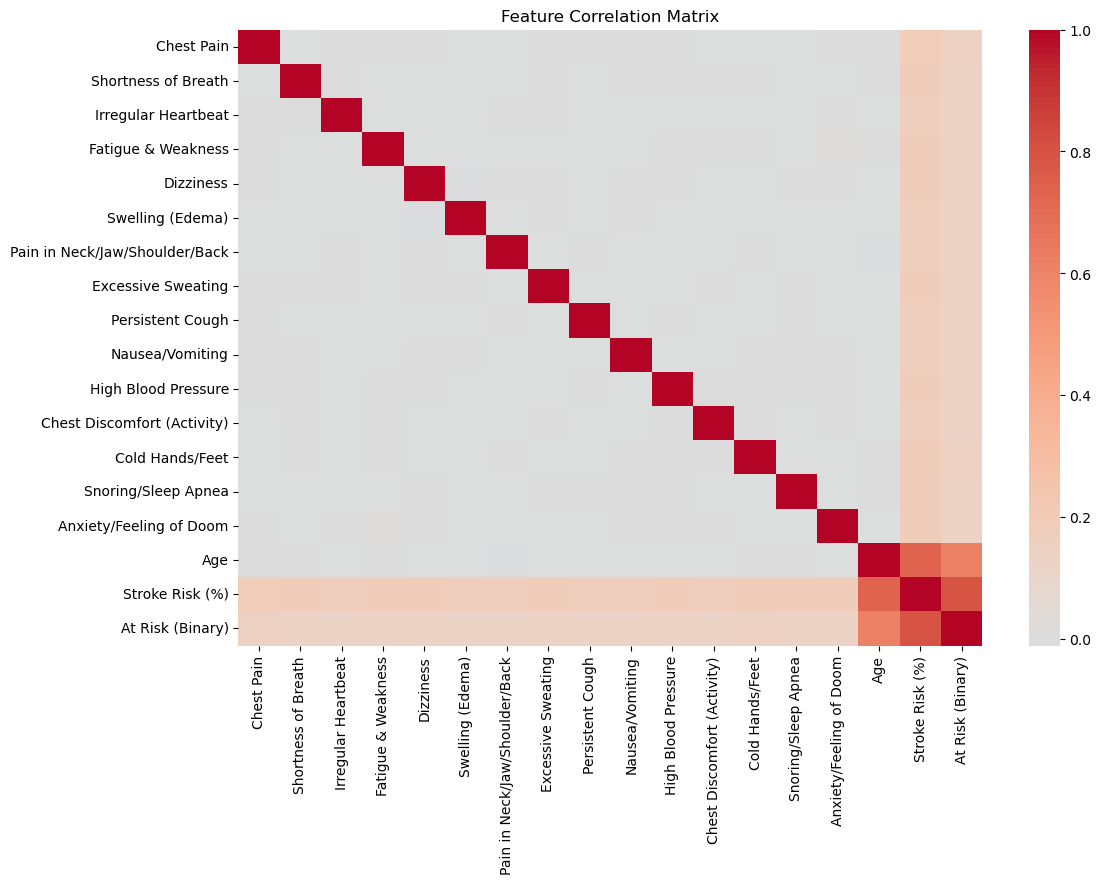

In [36]:
corr = df.corr()

plt.figure(figsize=(12,8))

import seaborn as sns

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

# Pre-Modeling Preparation

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Stroke Risk (%)", "At Risk (Binary)"])
y = df["Stroke Risk (%)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

rmse = np.sqrt(mse)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

# إنشاء الجدول
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"],
    "Value": [mae, mse, rmse, mape, r2, adj_r2]
})

print(results)

        Metric     Value
0          MAE  0.042912
1          MSE  0.158986
2         RMSE  0.398731
3         MAPE  0.000837
4           R2  0.999212
5  Adjusted R2  0.999211


# Feature Selection


## StrokeRisk=b0​+b1​X1​+b2​X2​+...

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model = LinearRegression()

model.fit(X_scaled, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["abs_coef"] = importance["Coefficient"].abs()

importance.sort_values("abs_coef", ascending=False)

,Feature,Coefficient,abs_coef
15,Age,10.535315,10.535315
6,Pain in Neck/Jaw/Shoulder/Back,2.501289,2.501289
2,Irregular Heartbeat,2.499667,2.499667
9,Nausea/Vomiting,2.499561,2.499561
14,Anxiety/Feeling of Doom,2.499370,2.499370
0,Chest Pain,2.499357,2.499357
13,Snoring/Sleep Apnea,2.499201,2.499201
10,High Blood Pressure,2.499064,2.499064
12,Cold Hands/Feet,2.498647,2.498647
7,Excessive Sweating,2.498275,2.498275


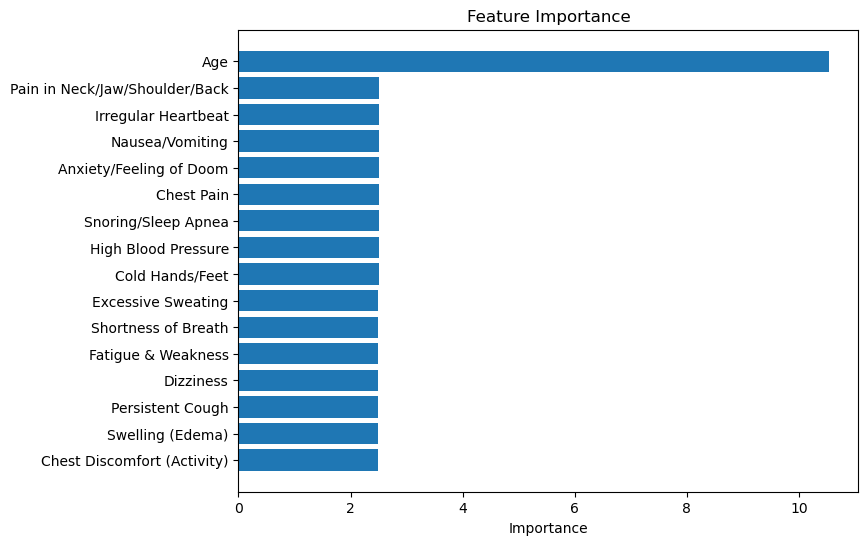

In [41]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values("abs_coef")

plt.figure(figsize=(8,6))

plt.barh(importance_sorted["Feature"], importance_sorted["abs_coef"])

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

### Feature Importance Analysis

The feature importance results show that Age is the most influential factor affecting stroke risk prediction.
All medical symptoms have similar coefficients, indicating that each symptom contributes approximately equally to the predicted stroke risk.
This suggests that stroke risk increases significantly with age, while symptoms moderately increase the overall risk score

# Model Comparison

### Linear Models

Linear Regression

Ridge

Lasso

ElasticNet

### Tree-Based Models

Decision Tree Regressor

Random Forest Regressor

Extra Trees Regressor

Gradient Boosting Regressor

### Boosting

AdaBoost Regressor

### Kernel-based

SVR

### Neighbors

KNeighborsRegressor

In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# =========================
# 1) Define X and y
# =========================
X = df.drop(columns=["Stroke Risk (%)", "At Risk (Binary)"])
y = df["Stroke Risk (%)"]

# =========================
# 2) Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# 3) Define models
# =========================
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01))
    ]),
    
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
    
    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(random_state=42, n_estimators=200))
    ]),
    
    "Extra Trees": Pipeline([
        ("model", ExtraTreesRegressor(random_state=42, n_estimators=200))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    
    "AdaBoost": Pipeline([
        ("model", AdaBoostRegressor(random_state=42, n_estimators=100))
    ]),
    
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor())
    ])
}

# =========================
# 4) Train and evaluate
# =========================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Adjusted R2": adj_r2
    })

# =========================
# 5) Results table
# =========================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="R2", ascending=False)

results_df = results_df.round(4)

display(results_df)

c:\Users\monasr\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\monasr\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\monasr\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\monasr\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

,Model,MAE,MSE,RMSE,MAPE,R2,Adjusted R2
0,Linear Regression,0.0429,0.1590,0.3987,0.0008,0.9992,0.9992
1,Ridge,0.0430,0.1590,0.3987,0.0008,0.9992,0.9992
2,Lasso,0.0709,0.1609,0.4011,0.0014,0.9992,0.9992
9,SVR,0.1071,0.1670,0.4086,0.0021,0.9992,0.9992
3,ElasticNet,0.1079,0.1672,0.4089,0.0022,0.9992,0.9992
7,Gradient Boosting,1.5926,4.0700,2.0174,0.0328,0.9798,0.9798
6,Extra Trees,1.8611,5.8850,2.4259,0.0371,0.9708,0.9708
5,Random Forest,2.1273,7.2530,2.6931,0.0427,0.9640,0.9640
10,KNN,3.2544,16.7369,4.0911,0.0644,0.9170,0.9169
8,AdaBoost,4.1836,26.3154,5.1299,0.0848,0.8695,0.8694


In [43]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Linear Regression


In [44]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [45]:
results_df["Rank"] = range(1, len(results_df) + 1)
results_df = results_df[["Rank", "Model", "MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"]]
display(results_df)

,Rank,Model,MAE,MSE,RMSE,MAPE,R2,Adjusted R2
0,1,Linear Regression,0.0429,0.1590,0.3987,0.0008,0.9992,0.9992
1,2,Ridge,0.0430,0.1590,0.3987,0.0008,0.9992,0.9992
2,3,Lasso,0.0709,0.1609,0.4011,0.0014,0.9992,0.9992
9,4,SVR,0.1071,0.1670,0.4086,0.0021,0.9992,0.9992
3,5,ElasticNet,0.1079,0.1672,0.4089,0.0022,0.9992,0.9992
7,6,Gradient Boosting,1.5926,4.0700,2.0174,0.0328,0.9798,0.9798
6,7,Extra Trees,1.8611,5.8850,2.4259,0.0371,0.9708,0.9708
5,8,Random Forest,2.1273,7.2530,2.6931,0.0427,0.9640,0.9640
10,9,KNN,3.2544,16.7369,4.0911,0.0644,0.9170,0.9169
8,10,AdaBoost,4.1836,26.3154,5.1299,0.0848,0.8695,0.8694


In [46]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=7,
    scoring="r2",
    n_jobs=-1
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 scores: [0.99910237 0.999251   0.9992208  0.99919801 0.9991182  0.99923158
 0.99918598]
Mean R2: 0.9991868481047849
Std: 5.243297450162495e-05


Model Validation

The Linear Regression model was evaluated using 7-fold cross-validation.
The model achieved an average R² score of 0.99918 with a very low standard deviation (0.00005), indicating excellent predictive performance and high model stability across different data splits

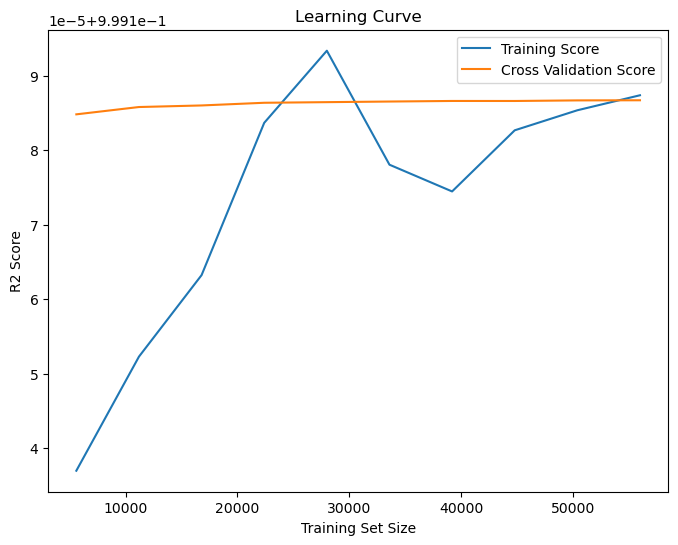

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression

model = LinearRegression()

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Cross Validation Score")

plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()


Learning Curve Analysis

The learning curve shows that both the training score and cross-validation score converge to a very high R² value close to 0.999.
The small gap between the curves indicates that the model generalizes well without signs of overfitting or underfitting.
As the training size increases, the model performance stabilizes, suggesting that the dataset is sufficient for training a reliable model

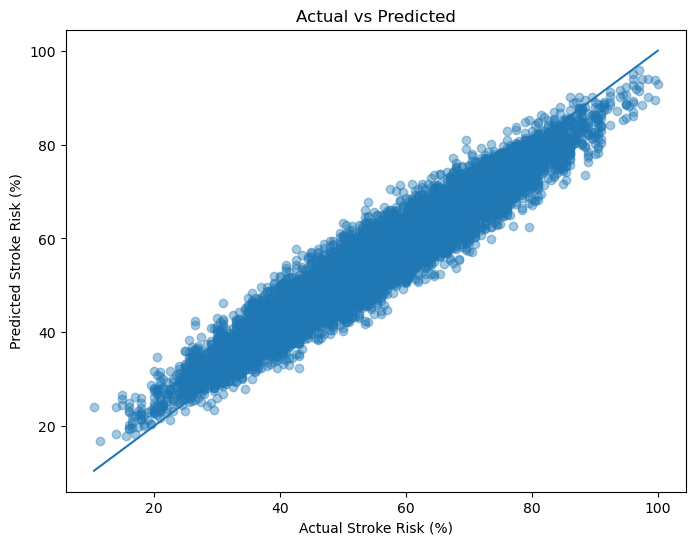

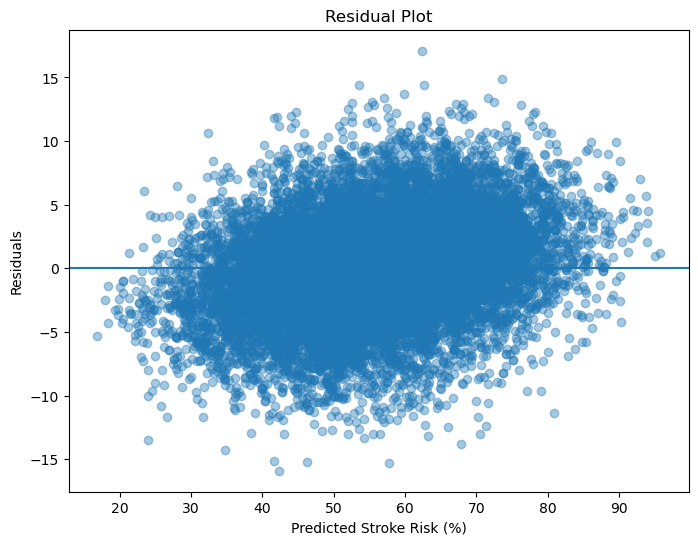

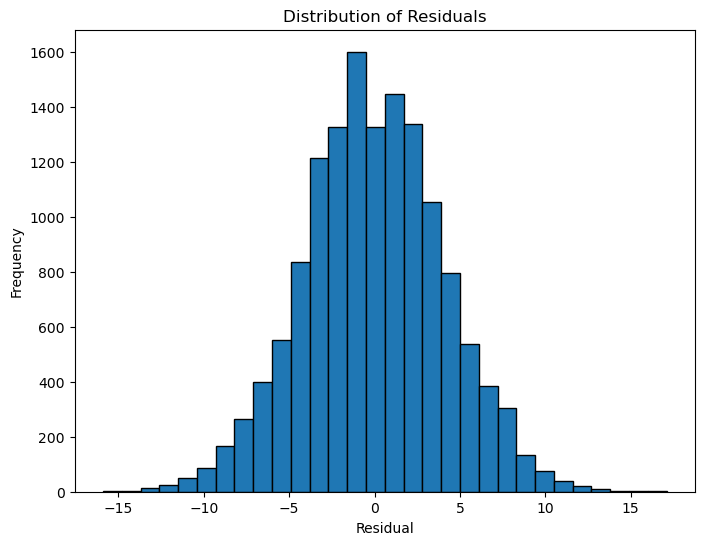

In [48]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Stroke Risk (%)")
plt.ylabel("Predicted Stroke Risk (%)")
plt.title("Actual vs Predicted")
plt.show()

# 2) Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(y=0)
plt.xlabel("Predicted Stroke Risk (%)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 3) Residual Distribution
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

In [49]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

LinearRegression()

In [50]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

importance_df = importance_df.sort_values("Importance Mean", ascending=False)

display(importance_df)

,Feature,Importance Mean,Importance Std
15,Age,1.095899,0.010962
13,Snoring/Sleep Apnea,0.062243,0.000517
6,Pain in Neck/Jaw/Shoulder/Back,0.062083,0.000487
10,High Blood Pressure,0.062055,0.000682
8,Persistent Cough,0.062025,0.000637
0,Chest Pain,0.062002,0.000492
2,Irregular Heartbeat,0.061985,0.000466
3,Fatigue & Weakness,0.061881,0.000566
14,Anxiety/Feeling of Doom,0.061833,0.000329
12,Cold Hands/Feet,0.061828,0.000372


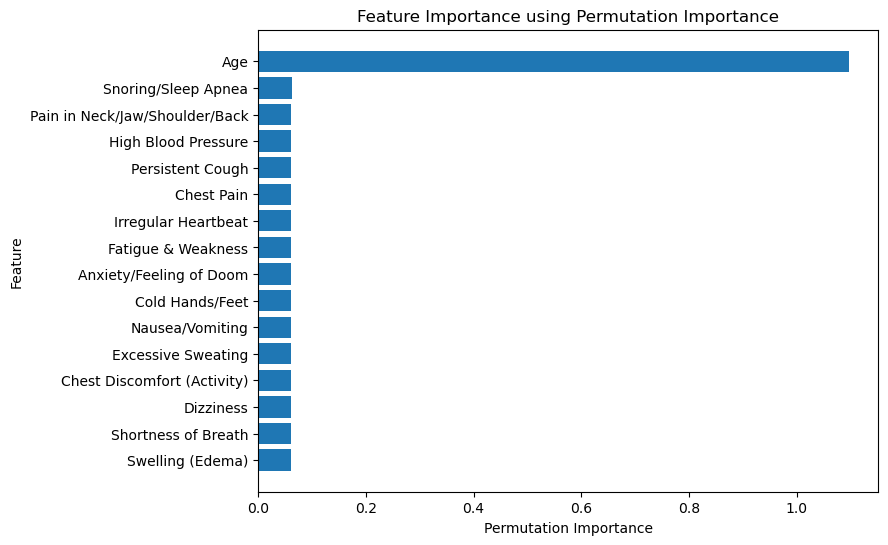

In [51]:
import matplotlib.pyplot as plt

importance_df_sorted = importance_df.sort_values("Importance Mean")

plt.figure(figsize=(8,6))
plt.barh(importance_df_sorted["Feature"], importance_df_sorted["Importance Mean"])

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Feature Importance using Permutation Importance")

plt.show()

Model Explainability

Permutation Importance analysis was performed to understand the contribution of each feature to the prediction of stroke risk.
The results indicate that Age is the most influential predictor, significantly affecting the model performance when permuted.
All symptom-related features have similar importance values, suggesting that each symptom contributes moderately and consistently to the predicted stroke risk.

# Patient Risk Simulation

In [54]:
# اعرف الأعمدة اللي الموديل اتدرب عليها
feature_names = X_train.columns

# اعمل صف مبدئي كله أصفار بنفس الأعمدة ونفس الترتيب
patient = pd.DataFrame([[0] * len(feature_names)], columns=feature_names)

# عدّل القيم اللي انت عايزها
patient.loc[0, "Age"] = 50
patient.loc[0, "Chest Pain"] = 1
patient.loc[0, "High Blood Pressure"] = 1
patient.loc[0, "Dizziness"] = 1

# التنبؤ
risk = best_model.predict(patient)[0]

print("Predicted Stroke Risk:", risk)

if risk >= 50:
    print("Patient Status: AT RISK")
else:
    print("Patient Status: NOT AT RISK")

Predicted Stroke Risk: 31.013303283958734
Patient Status: NOT AT RISK


In [55]:
import joblib

model_data = {
    "model": best_model,
    "features": list(X_train.columns)
}

joblib.dump(model_data, "stroke_regression_model.joblib")

['stroke_regression_model.joblib']